# 1D Gradient-Damage Bar — Thermal Fragmentation

Same family of problems as the QS vs Dynamic notebook, but with a different
physics setup chosen so that we can watch **fragmentation**:

- the bar is **mechanically free** at both ends (no displacement BC),
- a uniform thermal strain $\theta(t)$ is imposed and ramped up,
- the elastic foundation $\Lambda^2$ both pins the rigid-body mode and creates
  the tension that drives damage when the bar tries to expand.

What we want to see in the damage profile $\alpha(\hat x)$:

1. First damage band near $\hat x = 1/2$ (by symmetry).
2. Then a **second generation** of bands in the middle of each fragment.
3. And so on — a hierarchy of crack generations as $\theta$ grows.


## Model in short

State on $\hat x \in [0,1]$: displacement $\hat u(\hat x, t)$ and damage
$\alpha(\hat x, t) \in [0,1]$. The thermal load is a uniform imposed strain
$\theta(t)$, scalar in $\hat x$.

### Effective strain

The elastic strain is the mechanical strain minus the imposed thermal one:
$$\varepsilon_e(\hat x, t) = \hat u'(\hat x, t) - \theta(t).$$

### Time scales and $\eta$

Two times again: fast wave time $\tau$ (scale $L/c_0$) and slow loading time
$t$ (scale $t_0^\text{load}$, here the time to ramp $\theta$ from $0$ to
$\theta_{\max}$).
$$\eta = \frac{L/c_0}{t_0^\text{load}}.$$
The kinetic energy in slow time picks up the usual $\eta^2$. The loading
interval is normalized to $t \in [0,1]$.

### Dimensionless energies

Foundation parameter $\Lambda^2 = kL^2/E_0$, relative damage length
$\hat\ell = \ell/L$:
$$
\hat P(\hat u, \alpha; \theta) =
\tfrac{1}{2}\!\int_0^1\!\left[(1-\alpha)^2\,(\hat u' - \theta)^2
+ \Lambda^2 \hat u^2\right]\,d\hat x
$$
$$
\hat S(\alpha) = \int_0^1\!\left[\alpha + \hat\ell^2 (\alpha')^2\right]\,d\hat x
\quad\text{(AT1)}
$$
$$
\hat K(\dot{\hat u}) = \tfrac{\eta^2}{2}\!\int_0^1 \dot{\hat u}^2\,d\hat x
$$

### Governing equations

**QS** ($\eta = 0$): minimize $\hat P + \hat S$ over $(\hat u, \alpha)$, with
$\dot\alpha \ge 0$.

**Dynamic** ($\eta > 0$):
$$
\eta^2 \ddot{\hat u} = \big((1-\alpha)^2 (\hat u' - \theta)\big)' - \Lambda^2 \hat u,
$$
plus the same gradient-damage VI for $\alpha$.

### BCs (this is what changed)

- $\hat u$: **free** at both ends. No Dirichlet on $\hat u$. The foundation
  $\Lambda^2 \hat u^2$ keeps the bilinear form coercive (no rigid-body mode)
  and is what creates internal stress when $\theta(t)$ grows.
- $\alpha$: **free** at both ends. Natural Neumann
  $\alpha'(0) = \alpha'(1) = 0$ from the gradient term; damage may live anywhere.
- For the dynamic problem, $\hat v$ and $\hat a$ also carry no Dirichlet.

### Loading

Smooth ramp
$\theta(t) = \dot\theta_p(\sqrt{T_0^2 + t^2} - T_0)$
on $t \in [0,1]$, with $\dot\theta_p$ chosen so $\theta(1) = \theta_{\max}$.


## Imports

In [1]:
import os

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import dolfinx
from dolfinx import mesh as df_mesh, fem
import dolfinx.fem.petsc
import ufl

from mpi4py import MPI
from petsc4py import PETSc

comm = MPI.COMM_WORLD


## `SNESProblem` helper

Same wrapper as the QS / Dynamic notebook. Packages a UFL residual + unknown
into the callbacks `PETSc.SNES` wants.


In [2]:
class SNESProblem:
    def __init__(self, F, u, bcs, J=None):
        V = u.function_space
        du = ufl.TrialFunction(V)
        self.L = fem.form(F)
        if J is None:
            self.a = fem.form(ufl.derivative(F, u, du))
        else:
            self.a = fem.form(J)
        self.bcs = bcs
        self.u = u

    def F(self, snes, x, F):
        x.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
        x.copy(self.u.x.petsc_vec)
        self.u.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )
        with F.localForm() as f_local:
            f_local.set(0.0)
        fem.petsc.assemble_vector(F, self.L)
        fem.petsc.apply_lifting(F, [self.a], bcs=[self.bcs], x0=[x], alpha=-1.0)
        F.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
        fem.petsc.set_bc(F, self.bcs, x, -1.0)

    def J(self, snes, x, J, P):
        J.zeroEntries()
        fem.petsc.assemble_matrix(J, self.a, bcs=self.bcs)
        J.assemble()


## Parameters

Independent dimensionless parameters: $\hat\ell$, $\Lambda$, $\eta$.

For fragmentation we want a stiff-ish foundation (so the post-crack stress
recovery length $\sim 1/\Lambda$ is short and several cracks fit on $[0,1]$)
and a small damage length $\hat\ell$ so cracks are sharp.

Step-count based, like before:
- `N_steps_qs`  = QS load steps,
- `N_steps_dyn` = dynamic time steps (so $\Delta t = 1/N_\text{steps,dyn}$),
- `N_snapshots` = how many damage profiles to record across the loading for
  the fragmentation plot.


In [3]:
model_parameters = {
    "l_hat":  0.02,   # relative damage length l/L
    "Lambda": 10.0,    # stiff-ish foundation -> short recovery length -> multiple generations
    "eta":    1e-2,   # wave / loading time. small -> QS-like
}

mesh_parameters = {"nx": 200}

loading_parameters = {
    "theta_max":   4.0,   # peak thermal strain (dimensionless)
    "T0":          1.0,   # smoothing window at t=0
    "N_steps_qs":  20,
    "N_steps_dyn": 60,
    "N_snapshots": 15,     # how many alpha profiles to save for fragmentation plot
}

AltMin_parameters  = {"max_iter": 500, "tol": 1e-7}
Newmark_parameters = {"beta": 0.25, "gamma": 0.5}

if comm.rank == 0:
    for d in (model_parameters, mesh_parameters, loading_parameters,
              AltMin_parameters, Newmark_parameters):
        print(d)


{'l_hat': 0.02, 'Lambda': 10.0, 'eta': 0.01}
{'nx': 200}
{'theta_max': 4.0, 'T0': 1.0, 'N_steps_qs': 20, 'N_steps_dyn': 60, 'N_snapshots': 15}
{'max_iter': 500, 'tol': 1e-07}
{'beta': 0.25, 'gamma': 0.5}


## Mesh and function spaces

Uniform 1D mesh, $P_1$ Lagrange for both $\hat u$ and $\alpha$. No facet tags
this time: there is no reaction force to integrate (free ends carry zero
stress); we track the **mean stress** instead.


In [4]:
domain = df_mesh.create_interval(comm, mesh_parameters["nx"], (0.0, 1.0))
gdim = domain.topology.dim    # 1
fdim = gdim - 1               # 0

V_u     = fem.functionspace(domain, ("Lagrange", 1))
V_alpha = fem.functionspace(domain, ("Lagrange", 1))

# state at "current" time n
u     = fem.Function(V_u, name="Displacement")
v     = fem.Function(V_u, name="Velocity")
a     = fem.Function(V_u, name="Acceleration")
# state at "new" time n+1
u_new = fem.Function(V_u)
v_new = fem.Function(V_u)
a_new = fem.Function(V_u)

# damage + bounds for the VI
alpha          = fem.Function(V_alpha, name="Damage")
alpha_old_iter = fem.Function(V_alpha)
alpha_lb       = fem.Function(V_alpha)
alpha_ub       = fem.Function(V_alpha)

dx = ufl.Measure("dx", domain=domain)


## Boundary conditions

This is what differs from the previous notebook:

- **No Dirichlet on $\hat u$**: free mechanical ends. The foundation
  $\Lambda^2 \hat u^2$ keeps the bilinear form coercive (kills the
  rigid-body mode) and creates the stress that drives damage as $\theta$
  ramps up.
- **No Dirichlet on $\alpha$**: the gradient term gives the homogeneous
  Neumann BC $\alpha'(0) = \alpha'(1) = 0$ on its own. Damage is free to
  live anywhere.
- Same for $\hat v$, $\hat a$ in the dynamic problem.

The thermal strain $\theta(t)$ enters **inside** the energy density
(through $\varepsilon_e = \hat u' - \theta$), not through any BC.


In [5]:
# Mechanically free everywhere -> no Dirichlet for u, v, a.
# Damage natural Neumann everywhere -> no Dirichlet for alpha (the VI bounds
# still pin alpha in [alpha_lb, alpha_ub], that's all we need).
bcs_u     = []
bcs_v     = []
bcs_a     = []
bcs_alpha = []


## Energies and residuals

Define $\hat P$, $\hat S$, $\hat K$ once and reuse them in both solvers.

The thermal strain $\theta(t)$ is wrapped as a `fem.Constant` so we can
update it each step without rebuilding any forms. The effective strain is
$\hat u' - \theta$.

There is no boundary reaction to record (free ends $\Rightarrow$ $\sigma=0$
at the endpoints), so we record the **mean stress**
$\bar\sigma(t) = \int_0^1 (1-\alpha)^2 (\hat u' - \theta)\,d\hat x$
as a scalar load indicator instead.


In [6]:
# wrap parameters as fem.Constant so they can live in UFL forms
Lambda_c  = fem.Constant(domain, PETSc.ScalarType(model_parameters["Lambda"]))
l_hat_c   = fem.Constant(domain, PETSc.ScalarType(model_parameters["l_hat"]))
eta_c     = fem.Constant(domain, PETSc.ScalarType(model_parameters["eta"]))
delta_t_c = fem.Constant(domain, PETSc.ScalarType(1.0 / loading_parameters["N_steps_dyn"]))
theta_c   = fem.Constant(domain, PETSc.ScalarType(0.0))   # imposed uniform thermal strain

# strain and stress in 1D, now with the thermal strain
def elastic_strain(w, theta_): return w.dx(0) - theta_
def stress(w, alpha_, theta_): return (1.0 - alpha_)**2 * elastic_strain(w, theta_)

# energy densities (non-dim)
strain_e_density     = 0.5 * (1.0 - alpha)**2 * elastic_strain(u, theta_c)**2
foundation_e_density = 0.5 * Lambda_c**2 * u**2
fracture_e_density   = alpha + l_hat_c**2 * alpha.dx(0)**2   # AT1
kinetic_e_density    = 0.5 * eta_c**2 * v**2

# integrated energies
strain_energy     = strain_e_density     * dx
foundation_energy = foundation_e_density * dx
potential_energy  = strain_energy + foundation_energy
fracture_energy   = fracture_e_density   * dx
kinetic_energy    = kinetic_e_density    * dx

# scalar forms for post-processing
strain_energy_form     = fem.form(strain_energy)
foundation_energy_form = fem.form(foundation_energy)
fracture_energy_form   = fem.form(fracture_energy)
kinetic_energy_form    = fem.form(kinetic_energy)
mean_stress_form       = fem.form(stress(u, alpha, theta_c) * dx)   # integral over (0,1) = mean stress
error_L2_alpha_form    = fem.form((alpha - alpha_old_iter)**2 * dx)

# test functions
u_test     = ufl.TestFunction(V_u)
alpha_test = ufl.TestFunction(V_alpha)

# QS residuals: dPi/du and dPi/dalpha with Pi = P + S
Res_u_qs     = ufl.derivative(potential_energy, u, u_test)
Res_alpha_qs = ufl.derivative(potential_energy + fracture_energy, alpha, alpha_test)

# Dynamic acceleration residual (slow time): eta^2 * a_new * test + dP/du
# (u will be replaced by its Newmark expression in the dynamic block below)
Res_acc = eta_c**2 * a_new * u_test * dx + ufl.derivative(potential_energy, u, u_test)


## Loading

Smooth ramp built with `sympy` so $\dot\theta$ and $\ddot\theta$ come out
analytically (needed by Newmark for consistency in slow time).
$\dot\theta_p$ is tuned so $\theta(1) = \theta_{\max}$.


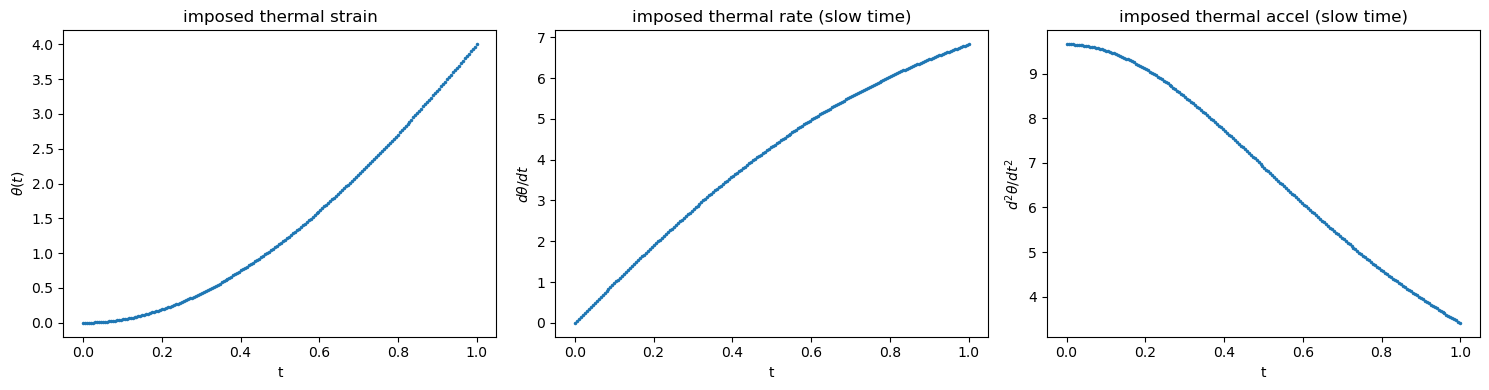

In [7]:
t_sp     = sp.Symbol("t", real=True)
T0_v     = loading_parameters["T0"]
ThMax_v  = loading_parameters["theta_max"]

# pick thetadot_p s.t. theta(1) = theta_max
Thdot_p = ThMax_v / (np.sqrt(T0_v**2 + 1.0**2) - T0_v)

Theta_sp     = Thdot_p * (sp.sqrt(T0_v**2 + t_sp**2) - T0_v)
ThetaDot_sp  = sp.diff(Theta_sp,    t_sp)
ThetaDDot_sp = sp.diff(ThetaDot_sp, t_sp)

Theta_fn     = sp.lambdify(t_sp, Theta_sp,     "numpy")
ThetaDot_fn  = sp.lambdify(t_sp, ThetaDot_sp,  "numpy")
ThetaDDot_fn = sp.lambdify(t_sp, ThetaDDot_sp, "numpy")

if comm.rank == 0:
    t_grid = np.linspace(0.0, 1.0, 200)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(t_grid, Theta_fn(t_grid), marker=".", linestyle="none", markersize=3)
    axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\theta(t)$")
    axes[0].set_title("imposed thermal strain")
    axes[1].plot(t_grid, ThetaDot_fn(t_grid), marker=".", linestyle="none", markersize=3)
    axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$d\theta/dt$")
    axes[1].set_title("imposed thermal rate (slow time)")
    axes[2].plot(t_grid, ThetaDDot_fn(t_grid), marker=".", linestyle="none", markersize=3)
    axes[2].set_xlabel("t"); axes[2].set_ylabel(r"$d^2\theta/dt^2$")
    axes[2].set_title("imposed thermal accel (slow time)")
    plt.tight_layout(); plt.show()


## QS solver

At each load level update $\theta$, then alternate:
1. solve linear elasticity for $\hat u$ at fixed $\alpha$ (`ksponly` + LU),
2. solve bound-constrained damage for $\alpha$ at fixed $\hat u$
   (`vinewtonrsls`),

until $\|\alpha^{(k+1)}-\alpha^{(k)}\|_{L^2}$ < tol. Then push the
irreversibility lower bound: $\alpha_\text{lb} \leftarrow \alpha$.


In [8]:
J_u_qs     = ufl.derivative(Res_u_qs,     u,     ufl.TrialFunction(V_u))
J_alpha_qs = ufl.derivative(Res_alpha_qs, alpha, ufl.TrialFunction(V_alpha))

elastic_problem_qs = SNESProblem(Res_u_qs,     u,     bcs_u,     J=J_u_qs)
damage_problem_qs  = SNESProblem(Res_alpha_qs, alpha, bcs_alpha, J=J_alpha_qs)

b_u_qs       = fem.petsc.create_vector(V_u)
J_u_qs_m     = fem.petsc.create_matrix(elastic_problem_qs.a)
b_alpha_qs   = fem.petsc.create_vector(V_alpha)
J_alpha_qs_m = fem.petsc.create_matrix(damage_problem_qs.a)

# elastic solver (linear problem)
solver_u_qs = PETSc.SNES().create()
solver_u_qs.setType("ksponly")
solver_u_qs.setFunction(elastic_problem_qs.F, b_u_qs)
solver_u_qs.setJacobian(elastic_problem_qs.J, J_u_qs_m)
solver_u_qs.setTolerances(rtol=1.0e-9, max_it=50)
solver_u_qs.getKSP().setType("preonly")
solver_u_qs.getKSP().getPC().setType("lu")
solver_u_qs.getKSP().getPC().setFactorSolverType("mumps")

# damage solver (variational inequality)
solver_alpha_qs = PETSc.SNES().create()
solver_alpha_qs.setType("vinewtonrsls")
solver_alpha_qs.setFunction(damage_problem_qs.F, b_alpha_qs)
solver_alpha_qs.setJacobian(damage_problem_qs.J, J_alpha_qs_m)
solver_alpha_qs.setTolerances(rtol=1.0e-9, max_it=50)
solver_alpha_qs.getKSP().setType("preonly")
solver_alpha_qs.getKSP().getPC().setType("lu")
solver_alpha_qs.setVariableBounds(alpha_lb.x.petsc_vec, alpha_ub.x.petsc_vec)
solver_alpha_qs.getKSP().getPC().setFactorSolverType("mumps")


### QS load loop

Sample the thermal ramp at $N$ slow-time points $t_i = i/N$, $i=1,\dots,N$,
so recorded arrays have length exactly $N =$ `N_steps_qs`.

Also save $\alpha(\hat x)$ at `N_snapshots` evenly spaced indices — those
profiles are the **fragmentation generations**.


In [9]:
# Reset state
u.x.array[:] = 0.0
v.x.array[:] = 0.0
a.x.array[:] = 0.0
alpha.x.array[:]    = 0.0
alpha_lb.x.array[:] = 0.0
alpha_ub.x.array[:] = 1.0
theta_c.value       = 0.0

qs = {"t": [], "theta": [], "sigma_bar": [],
      "P_el": [], "P_f": [], "S": [], "total": []}

N_qs   = loading_parameters["N_steps_qs"]
N_snap = loading_parameters["N_snapshots"]
t_grid_qs   = np.linspace(0.0, 1.0, N_qs + 1)[1:]
snap_idx_qs = set(np.unique(np.linspace(0, N_qs - 1, N_snap, dtype=int)).tolist())

qs_snapshots = []   # list of dicts: {"step", "t", "theta", "alpha"}

for i, ti in enumerate(t_grid_qs):
    theta_c.value = float(Theta_fn(ti))

    # alt min: u <-> alpha until alpha stops changing
    n_alt = 0
    for n_alt in range(1, AltMin_parameters["max_iter"] + 1):
        solver_u_qs.solve(None, u.x.petsc_vec)
        u.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )
        solver_alpha_qs.solve(None, alpha.x.petsc_vec)
        alpha.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )

        err = comm.allreduce(fem.assemble_scalar(error_L2_alpha_form), op=MPI.SUM)
        err_alpha = float(np.sqrt(max(err, 0.0)))
        alpha_old_iter.x.array[:] = alpha.x.array

        if err_alpha <= AltMin_parameters["tol"]:
            break

    # irreversibility: lower bound = current alpha for the next step
    alpha_lb.x.array[:] = alpha.x.array

    # record scalars
    qs["t"].append(float(ti))
    qs["theta"].append(float(theta_c.value))
    qs["sigma_bar"].append(comm.allreduce(fem.assemble_scalar(mean_stress_form),    op=MPI.SUM))
    qs["P_el"].append(comm.allreduce(fem.assemble_scalar(strain_energy_form),       op=MPI.SUM))
    qs["P_f"].append(comm.allreduce(fem.assemble_scalar(foundation_energy_form),   op=MPI.SUM))
    qs["S"].append(comm.allreduce(fem.assemble_scalar(fracture_energy_form),       op=MPI.SUM))
    qs["total"].append(qs["P_el"][-1] + qs["P_f"][-1] + qs["S"][-1])

    # snapshot for fragmentation plot
    if i in snap_idx_qs:
        qs_snapshots.append({
            "step":  i,
            "t":     float(ti),
            "theta": float(theta_c.value),
            "alpha": alpha.x.array.copy(),
        })

    if comm.rank == 0 and ((i + 1) % 10 == 0 or i == N_qs - 1):
        print(f"QS step {i+1:3d}/{N_qs}: "
              f"theta={qs['theta'][-1]:.3f}  sigma_bar={qs['sigma_bar'][-1]:.4f}  "
              f"S={qs['S'][-1]:.4f}  alt_min_it={n_alt}")

u_qs_final     = u.x.array.copy()
alpha_qs_final = alpha.x.array.copy()
for k in qs: qs[k] = np.array(qs[k])


QS step  10/20: theta=1.140  sigma_bar=-0.4966  S=0.1151  alt_min_it=26
QS step  20/20: theta=4.000  sigma_bar=-0.0431  S=0.8617  alt_min_it=82


### QS plots

Two views of the QS run:

1. Energies and mean stress vs $\theta$.
2. **Fragmentation plot**: damage profile $\alpha(\hat x)$ at the saved
   snapshots, overlaid on one set of axes and colored by load level, so the
   successive generations of cracks are visible.


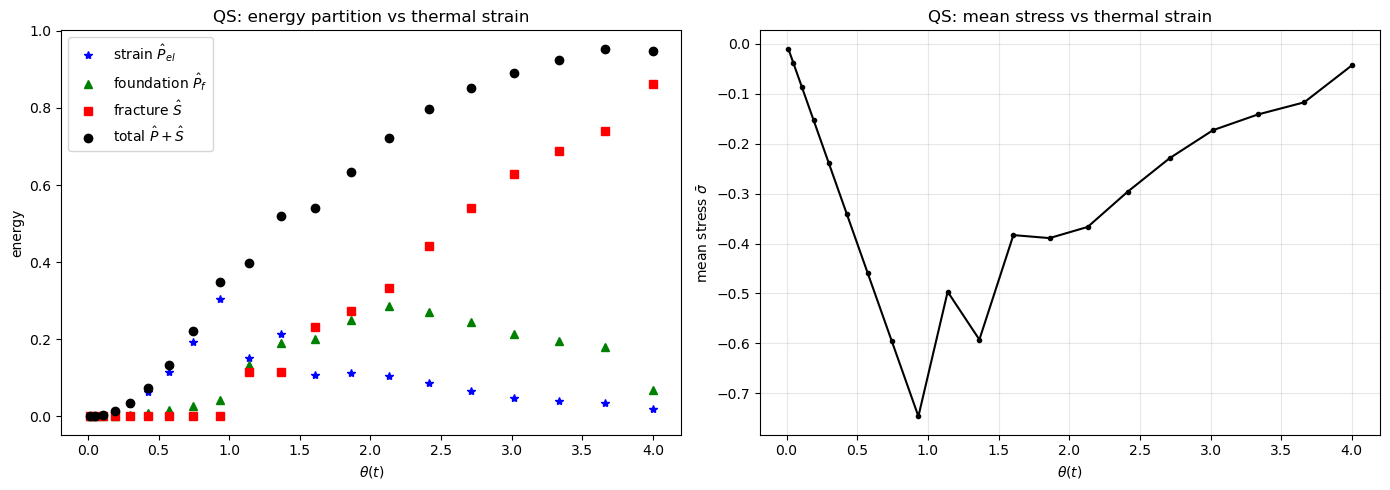

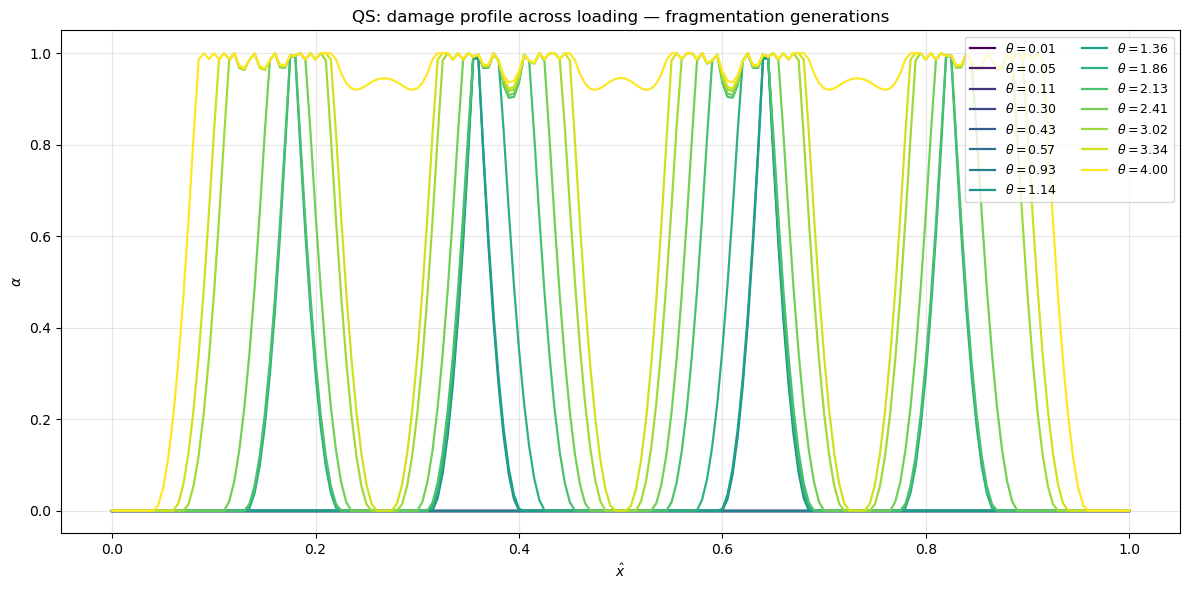

In [10]:
x_alpha  = V_alpha.tabulate_dof_coordinates()[:, 0]
ix_alpha = np.argsort(x_alpha)

if comm.rank == 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(qs["theta"], qs["P_el"],  "b*", label=r"strain $\hat P_{el}$")
    axes[0].plot(qs["theta"], qs["P_f"],   "g^", label=r"foundation $\hat P_f$")
    axes[0].plot(qs["theta"], qs["S"],     "rs", label=r"fracture $\hat S$")
    axes[0].plot(qs["theta"], qs["total"], "ko", label=r"total $\hat P+\hat S$")
    axes[0].set_xlabel(r"$\theta(t)$"); axes[0].set_ylabel("energy")
    axes[0].set_title("QS: energy partition vs thermal strain")
    axes[0].legend()

    axes[1].plot(qs["theta"], qs["sigma_bar"], "k.-")
    axes[1].set_xlabel(r"$\theta(t)$")
    axes[1].set_ylabel(r"mean stress $\bar\sigma$")
    axes[1].set_title("QS: mean stress vs thermal strain")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

# --- fragmentation snapshots ---
if comm.rank == 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.cm.viridis
    n = len(qs_snapshots)
    for k, snap in enumerate(qs_snapshots):
        color = cmap(k / max(1, n - 1))
        ax.plot(x_alpha[ix_alpha], snap["alpha"][ix_alpha],
                color=color, lw=1.6,
                label=fr"$\theta={snap['theta']:.2f}$")
    ax.set_xlabel(r"$\hat x$"); ax.set_ylabel(r"$\alpha$")
    ax.set_title("QS: damage profile across loading — fragmentation generations")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9, loc="upper right")
    plt.tight_layout(); plt.show()


## Dynamic solver (Newmark-$\beta$ + alt-min)

In slow time:
$$
\eta^2 \ddot{\hat u} = \big((1-\alpha)^2 (\hat u' - \theta)\big)' - \Lambda^2 \hat u.
$$
Newmark-$\beta$ with $\beta = 1/4$, $\gamma = 1/2$ (average-acceleration,
no numerical damping):
$$
\hat u_{n+1} = \hat u_n + \Delta t\,\dot{\hat u}_n
              + \tfrac{\Delta t^2}{2}\big((1-2\beta)a_n + 2\beta\,a_{n+1}\big),
$$
$$
\dot{\hat u}_{n+1} = \dot{\hat u}_n
                    + \Delta t\big((1-\gamma)a_n + \gamma a_{n+1}\big).
$$
At each step alt-min between $a_{n+1}$ (linear) and $\alpha_{n+1}$ (VI). Once
converged, propagate $u_{n+1}, v_{n+1}$ with the formulas above.

Time step $\Delta t = 1 / N_\text{steps,dyn}$.


In [11]:
beta_v  = Newmark_parameters["beta"]
gamma_v = Newmark_parameters["gamma"]

# Newmark expressions (UFL form, used for symbolic substitution)
def u_newmark(u_, v_, a_, a_new_, dt):
    return u_ + dt*v_ + 0.5*dt**2 * ((1.0 - 2.0*beta_v)*a_ + 2.0*beta_v*a_new_)

def v_newmark(v_, a_, a_new_, dt):
    return v_ + dt*((1.0 - gamma_v)*a_ + gamma_v*a_new_)

# swap u -> u_newmark in the acceleration residual.
Res_acc_newmark = ufl.replace(Res_acc, {
    u: u_newmark(u, v, a, a_new, delta_t_c),
})

# alpha residual depends on u via the strain energy -> same swap
Res_alpha_dyn = ufl.replace(Res_alpha_qs, {
    u: u_newmark(u, v, a, a_new, delta_t_c),
})

J_acc_newmark = ufl.derivative(Res_acc_newmark, a_new, ufl.TrialFunction(V_u))
J_alpha_dyn   = ufl.derivative(Res_alpha_dyn,   alpha, ufl.TrialFunction(V_alpha))

acc_problem        = SNESProblem(Res_acc_newmark, a_new, bcs_a,     J=J_acc_newmark)
damage_problem_dyn = SNESProblem(Res_alpha_dyn,   alpha, bcs_alpha, J=J_alpha_dyn)

b_acc_dyn     = fem.petsc.create_vector(V_u)
J_acc_dyn_m   = fem.petsc.create_matrix(acc_problem.a)
b_alpha_dyn   = fem.petsc.create_vector(V_alpha)
J_alpha_dyn_m = fem.petsc.create_matrix(damage_problem_dyn.a)

# acceleration solver (linear)
solver_acc = PETSc.SNES().create()
solver_acc.setType("ksponly")
solver_acc.setFunction(acc_problem.F, b_acc_dyn)
solver_acc.setJacobian(acc_problem.J, J_acc_dyn_m)
solver_acc.setTolerances(rtol=1.0e-9, max_it=50)
solver_acc.getKSP().setType("preonly")
solver_acc.getKSP().getPC().setType("lu")
solver_acc.getKSP().getPC().setFactorSolverType("mumps")

# damage solver (VI)
solver_alpha_dyn = PETSc.SNES().create()
solver_alpha_dyn.setType("vinewtonrsls")
solver_alpha_dyn.setFunction(damage_problem_dyn.F, b_alpha_dyn)
solver_alpha_dyn.setJacobian(damage_problem_dyn.J, J_alpha_dyn_m)
solver_alpha_dyn.setTolerances(rtol=1.0e-9, max_it=50)
solver_alpha_dyn.getKSP().setType("preonly")
solver_alpha_dyn.getKSP().getPC().setType("lu")
solver_alpha_dyn.setVariableBounds(alpha_lb.x.petsc_vec, alpha_ub.x.petsc_vec)
solver_alpha_dyn.getKSP().getPC().setFactorSolverType("mumps")

# keep delta_t_c consistent with N_steps_dyn
delta_t_c.value = 1.0 / loading_parameters["N_steps_dyn"]


### Dynamic time loop

Start at rest. Loop `N_steps_dyn` times with $\Delta t = 1/N$, updating
$\theta$ at the new time. Same snapshot logic as QS so we can compare the
fragmentation generations side-by-side.


In [12]:
# reset
u.x.array[:]     = 0.0; u_new.x.array[:] = 0.0
v.x.array[:]     = 0.0; v_new.x.array[:] = 0.0
a.x.array[:]     = 0.0; a_new.x.array[:] = 0.0
alpha.x.array[:]    = 0.0
alpha_lb.x.array[:] = 0.0
alpha_ub.x.array[:] = 1.0
theta_c.value       = 0.0

dyn = {"t": [], "theta": [], "sigma_bar": [],
       "K": [], "P_el": [], "P_f": [], "S": [], "total": []}

N_dyn = loading_parameters["N_steps_dyn"]
dt    = 1.0 / N_dyn

snap_idx_dyn = set(np.unique(np.linspace(0, N_dyn - 1, N_snap, dtype=int)).tolist())
dyn_snapshots = []

t_cur = 0.0
for step in range(N_dyn):
    t_cur += dt
    theta_c.value = float(Theta_fn(t_cur))

    # alt-min between a_new and alpha
    n_alt = 0
    for n_alt in range(1, AltMin_parameters["max_iter"] + 1):
        solver_acc.solve(None, a_new.x.petsc_vec)
        a_new.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )
        solver_alpha_dyn.solve(None, alpha.x.petsc_vec)
        alpha.x.petsc_vec.ghostUpdate(
            addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD
        )

        err = comm.allreduce(fem.assemble_scalar(error_L2_alpha_form), op=MPI.SUM)
        err_alpha = float(np.sqrt(max(err, 0.0)))
        alpha_old_iter.x.array[:] = alpha.x.array

        if err_alpha <= AltMin_parameters["tol"]:
            break

    # explicit Newmark update of u_new, v_new
    u_new.x.array[:] = (u.x.array
                        + dt * v.x.array
                        + 0.5 * dt**2 * ((1.0 - 2.0*beta_v) * a.x.array
                                          + 2.0*beta_v * a_new.x.array))
    v_new.x.array[:] = (v.x.array
                        + dt * ((1.0 - gamma_v) * a.x.array
                                + gamma_v * a_new.x.array))
    u_new.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
    v_new.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)

    # n+1 -> n
    u.x.array[:] = u_new.x.array
    v.x.array[:] = v_new.x.array
    a.x.array[:] = a_new.x.array
    alpha_lb.x.array[:] = alpha.x.array

    # record scalars
    dyn["t"].append(t_cur)
    dyn["theta"].append(float(theta_c.value))
    dyn["sigma_bar"].append(comm.allreduce(fem.assemble_scalar(mean_stress_form),    op=MPI.SUM))
    dyn["K"].append(comm.allreduce(fem.assemble_scalar(kinetic_energy_form),         op=MPI.SUM))
    dyn["P_el"].append(comm.allreduce(fem.assemble_scalar(strain_energy_form),       op=MPI.SUM))
    dyn["P_f"].append(comm.allreduce(fem.assemble_scalar(foundation_energy_form),   op=MPI.SUM))
    dyn["S"].append(comm.allreduce(fem.assemble_scalar(fracture_energy_form),       op=MPI.SUM))
    dyn["total"].append(dyn["K"][-1] + dyn["P_el"][-1] + dyn["P_f"][-1] + dyn["S"][-1])

    if step in snap_idx_dyn:
        dyn_snapshots.append({
            "step":  step,
            "t":     float(t_cur),
            "theta": float(theta_c.value),
            "alpha": alpha.x.array.copy(),
        })

    if comm.rank == 0 and ((step + 1) % 10 == 0 or step == N_dyn - 1):
        denom = max(1.0e-12, dyn["total"][-1])
        print(f"Dyn step {step+1:4d}/{N_dyn}: "
              f"t={t_cur:.4f}  theta={dyn['theta'][-1]:.3f}  "
              f"K/total={dyn['K'][-1]/denom:.2e}  alt_min_it={n_alt}")

u_dyn_final     = u.x.array.copy()
alpha_dyn_final = alpha.x.array.copy()
for k in dyn: dyn[k] = np.array(dyn[k])


Dyn step   10/60: t=0.1667  theta=0.133  K/total=1.79e-05  alt_min_it=1
Dyn step   20/60: t=0.3333  theta=0.522  K/total=4.25e-06  alt_min_it=1
Dyn step   30/60: t=0.5000  theta=1.140  K/total=1.41e-03  alt_min_it=10
Dyn step   40/60: t=0.6667  theta=1.949  K/total=5.26e-04  alt_min_it=3
Dyn step   50/60: t=0.8333  theta=2.914  K/total=3.18e-03  alt_min_it=11
Dyn step   60/60: t=1.0000  theta=4.000  K/total=8.06e-03  alt_min_it=33


### Dynamic plots

Same two views as QS: energies + mean stress vs $\theta$, and the
fragmentation snapshots. Comparing the two snapshot plots side by side is the
quickest way to see how inertia changes the crack pattern (number, spacing,
and onset of generations).


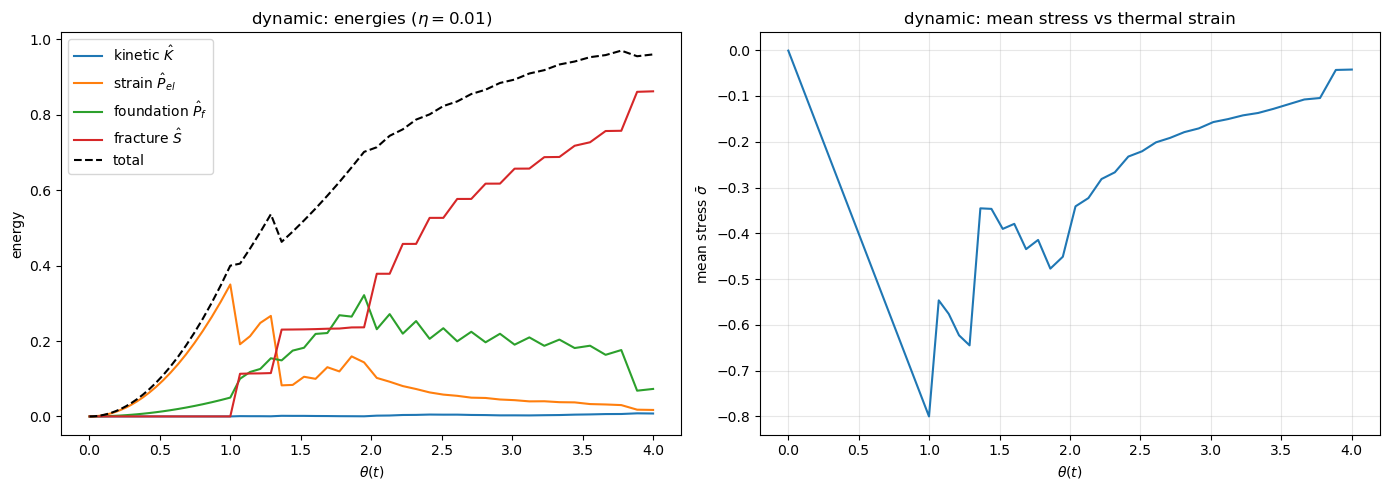

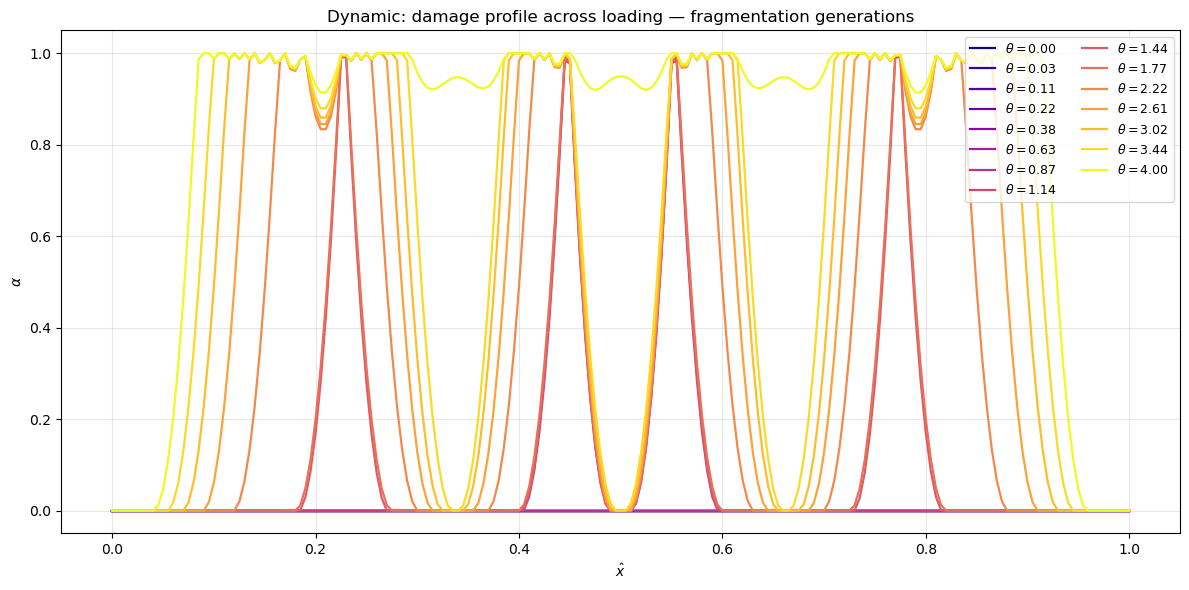

In [13]:
if comm.rank == 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(dyn["theta"], dyn["K"],     label=r"kinetic $\hat K$")
    axes[0].plot(dyn["theta"], dyn["P_el"],  label=r"strain $\hat P_{el}$")
    axes[0].plot(dyn["theta"], dyn["P_f"],   label=r"foundation $\hat P_f$")
    axes[0].plot(dyn["theta"], dyn["S"],     label=r"fracture $\hat S$")
    axes[0].plot(dyn["theta"], dyn["total"], "k--", label="total")
    axes[0].set_xlabel(r"$\theta(t)$"); axes[0].set_ylabel("energy")
    axes[0].set_title(r"dynamic: energies ($\eta=%g$)" % model_parameters["eta"])
    axes[0].legend()

    axes[1].plot(dyn["theta"], dyn["sigma_bar"])
    axes[1].set_xlabel(r"$\theta(t)$")
    axes[1].set_ylabel(r"mean stress $\bar\sigma$")
    axes[1].set_title("dynamic: mean stress vs thermal strain")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

# fragmentation snapshots (dynamic)
if comm.rank == 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.cm.plasma
    n = len(dyn_snapshots)
    for k, snap in enumerate(dyn_snapshots):
        color = cmap(k / max(1, n - 1))
        ax.plot(x_alpha[ix_alpha], snap["alpha"][ix_alpha],
                color=color, lw=1.6,
                label=fr"$\theta={snap['theta']:.2f}$")
    ax.set_xlabel(r"$\hat x$"); ax.set_ylabel(r"$\alpha$")
    ax.set_title("Dynamic: damage profile across loading — fragmentation generations")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9, loc="upper right")
    plt.tight_layout(); plt.show()


## QS vs Dynamic comparison

Both solvers ran on the same $\theta(t)$, so plotting against $\theta$ is a
fair comparison.

Layout:
- top-left: mean stress vs $\theta$,
- top-right: final damage profile $\alpha(\hat x)$ at $\theta = \theta_{\max}$,
- bottom (wide): all energies vs $\theta$, including the kinetic $\hat K$
  (only the dynamic solver has it).

A note on the "total" gap: $\text{Total}_\text{QS} = \hat P_{el}+\hat P_f+\hat S$
vs $\text{Total}_\text{dyn} = \hat K + \hat P_{el}+\hat P_f+\hat S$, so the
gap is driven by $\hat K$ plus a small overshoot in $\hat P_{el}$, $\hat P_f$
right after each new crack snaps in (no viscous damping — energy bounces
between $\hat K$, $\hat P_{el}$ and $\hat P_f$).

Figure also saved to `Output/`.


/tmp/ipykernel_2088891/4110790653.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.93])


Results saved to Output/
  - thermal_lhat_0.02_lam_10.0_eta_0.01_thmax_4.00_nQS_20_nDyn_60_nMesh_200_T0_1.0.png
  - thermal_lhat_0.02_lam_10.0_eta_0.01_thmax_4.00_nQS_20_nDyn_60_nMesh_200_T0_1.0.pdf


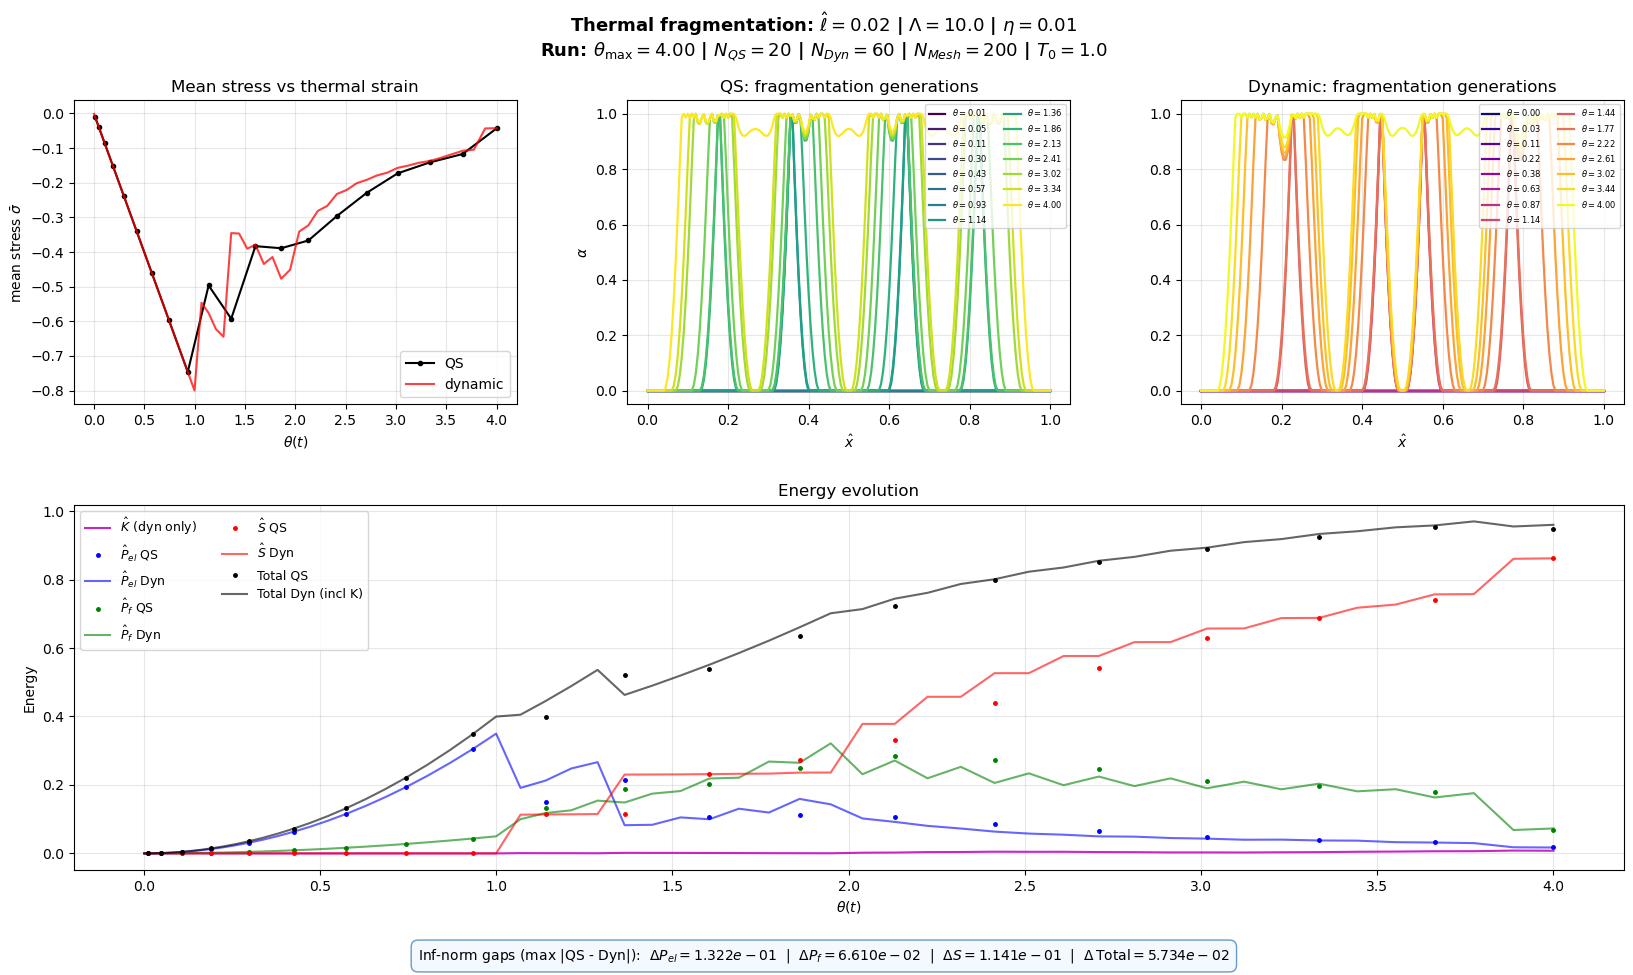

In [14]:
# --- inf-norm gaps QS vs Dyn (interp Dyn onto QS theta grid) ---
P_el_dyn_at_qs = np.interp(qs["theta"], dyn["theta"], dyn["P_el"])
P_f_dyn_at_qs  = np.interp(qs["theta"], dyn["theta"], dyn["P_f"])
S_dyn_at_qs    = np.interp(qs["theta"], dyn["theta"], dyn["S"])
tot_dyn_at_qs  = np.interp(qs["theta"], dyn["theta"], dyn["total"])

err_P_el = float(np.max(np.abs(qs["P_el"]  - P_el_dyn_at_qs)))
err_P_f  = float(np.max(np.abs(qs["P_f"]   - P_f_dyn_at_qs)))
err_S    = float(np.max(np.abs(qs["S"]     - S_dyn_at_qs)))
err_tot  = float(np.max(np.abs(qs["total"] - tot_dyn_at_qs)))

# --- comparison figure ---
if comm.rank == 0:
    fig = plt.figure(figsize=(20, 10))
    gs  = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.2], hspace=0.30, wspace=0.25)
    ax_force  = fig.add_subplot(gs[0, 0])
    ax_frag_qs = fig.add_subplot(gs[0, 1])
    ax_frag_dyn = fig.add_subplot(gs[0, 2])
    ax_energy = fig.add_subplot(gs[1, :])

    theta_max_val = float(np.max(qs["theta"]))
    n_steps_qs    = len(qs["theta"])
    n_steps_dyn   = len(dyn["theta"])
    eta_val       = model_parameters["eta"]
    ell_val       = model_parameters["l_hat"]
    lambda_val    = model_parameters["Lambda"]
    mesh_val      = mesh_parameters["nx"]
    smoth_val     = loading_parameters["T0"]

    header_text = (
        f"Thermal fragmentation: $\\hat\\ell={ell_val}$ | $\\Lambda={lambda_val}$ | $\\eta={eta_val}$\n"
        f"Run: $\\theta_{{\\max}}={theta_max_val:.2f}$ | $N_{{QS}}={n_steps_qs}$ | $N_{{Dyn}}={n_steps_dyn}$ | $N_{{Mesh}}={mesh_val}$ | $T_0={smoth_val}$"
    )
    fig.suptitle(header_text, fontsize=13, fontweight="bold", y=0.97)

    # (top-left) mean stress vs theta
    ax_force.plot(qs["theta"],  qs["sigma_bar"],  "k.-", label="QS")
    ax_force.plot(dyn["theta"], dyn["sigma_bar"], "r-",
                  label=r"dynamic", alpha=0.75)
    ax_force.set_xlabel(r"$\theta(t)$")
    ax_force.set_ylabel(r"mean stress $\bar\sigma$")
    ax_force.set_title("Mean stress vs thermal strain")
    ax_force.grid(True, alpha=0.3); ax_force.legend()

    # (bottom, wide) energy overview
    ax_energy.plot(dyn["theta"], dyn["K"],     "m-",  alpha=0.85,  label=r"$\hat K$ (dyn only)")
    ax_energy.plot(qs["theta"],  qs["P_el"],   "b.",  markersize=5, label=r"$\hat P_{el}$ QS")
    ax_energy.plot(dyn["theta"], dyn["P_el"],  "b-",  alpha=0.6,    label=r"$\hat P_{el}$ Dyn")
    ax_energy.plot(qs["theta"],  qs["P_f"],    "g.",  markersize=5, label=r"$\hat P_f$ QS")
    ax_energy.plot(dyn["theta"], dyn["P_f"],   "g-",  alpha=0.6,    label=r"$\hat P_f$ Dyn")
    ax_energy.plot(qs["theta"],  qs["S"],      "r.",  markersize=5, label=r"$\hat S$ QS")
    ax_energy.plot(dyn["theta"], dyn["S"],     "r-",  alpha=0.6,    label=r"$\hat S$ Dyn")
    ax_energy.plot(qs["theta"],  qs["total"],  "k.",  markersize=5, label="Total QS")
    ax_energy.plot(dyn["theta"], dyn["total"], "k-",  alpha=0.6,    label="Total Dyn (incl K)")
    ax_energy.set_xlabel(r"$\theta(t)$"); ax_energy.set_ylabel("Energy")
    ax_energy.set_title("Energy evolution")
    ax_energy.grid(True, alpha=0.3)
    ax_energy.legend(fontsize=9, ncol=2, loc="best")

    # (top-middle) qs_snapshots
    cmap_qs  = plt.cm.viridis
    n_q = len(qs_snapshots)
    for k, snap in enumerate(qs_snapshots):
        color = cmap_qs(k / max(1, n_q - 1))
        ax_frag_qs.plot(x_alpha[ix_alpha], snap["alpha"][ix_alpha],
                         color=color, lw=1.6,
                         label=fr"$\theta={snap['theta']:.2f}$")
    ax_frag_qs.set_xlabel(r"$\hat x$"); ax_frag_qs.set_ylabel(r"$\alpha$")
    ax_frag_qs.set_title("QS: fragmentation generations")
    ax_frag_qs.set_ylim(-0.05, 1.05)
    ax_frag_qs.grid(True, alpha=0.3)
    ax_frag_qs.legend(ncol=2, fontsize=6, loc="upper right")

    # (top-right) dyn_snapshots
    cmap_dyn = plt.cm.plasma
    n_d = len(dyn_snapshots)
    for k, snap in enumerate(dyn_snapshots):
        color = cmap_dyn(k / max(1, n_d - 1))
        ax_frag_dyn.plot(x_alpha[ix_alpha], snap["alpha"][ix_alpha],
                         color=color, lw=1.6,
                         label=fr"$\theta={snap['theta']:.2f}$")
    ax_frag_dyn.set_xlabel(r"$\hat x$")
    ax_frag_dyn.set_title(r"Dynamic: fragmentation generations")
    ax_frag_dyn.set_ylim(-0.05, 1.05)
    ax_frag_dyn.grid(True, alpha=0.3)
    ax_frag_dyn.legend(ncol=2, fontsize=6, loc="upper right")

    err_text = (
        f"Inf-norm gaps (max |QS - Dyn|):  "
        f"$\\Delta P_{{el}}={err_P_el:.3e}$  |  "
        f"$\\Delta P_f={err_P_f:.3e}$  |  "
        f"$\\Delta S={err_S:.3e}$  |  "
        f"$\\Delta\\,\\mathrm{{Total}}={err_tot:.3e}$"
    )
    fig.text(0.5, 0.015, err_text, ha="center", va="bottom", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.5", facecolor="aliceblue",
                       edgecolor="steelblue", alpha=0.8))

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])

    # save
    output_dir = "Output"
    os.makedirs(output_dir, exist_ok=True)
    filename_str = (
        f"thermal_lhat_{ell_val}_lam_{lambda_val}_eta_{eta_val}_"
        f"thmax_{theta_max_val:.2f}_nQS_{n_steps_qs}_nDyn_{n_steps_dyn}"
        f"_nMesh_{mesh_val}_T0_{smoth_val}"
    )
    png_path = os.path.join(output_dir, f"{filename_str}.png")
    pdf_path = os.path.join(output_dir, f"{filename_str}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path,            bbox_inches="tight")

    print(f"Results saved to {output_dir}/")
    print(f"  - {filename_str}.png")
    print(f"  - {filename_str}.pdf")

    plt.show()
